# Decay Amount Sweep Analysis

Analyze the amount sweep run where training reaches step 900, then several 100-step decay probes are launched from the same checkpoint with different final LR ratios.

The main question is whether the final validation loss after the 100-step decay changes meaningfully as the decay amount changes. With one seed and one checkpoint, the notebook can show descriptive and practical differences, but not formal statistical significance across random seeds.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [2]:
# Point this to the amount sweep run to analyze.
RUN_NAME = "wsd_intermediate_amount_sweep_20260605-154506"
LOG_DIR = Path("../logs") / RUN_NAME
RESULT_DIR = Path("../results") / RUN_NAME

assert LOG_DIR.exists(), f"Missing log directory: {LOG_DIR}"
assert (LOG_DIR / "metrics.jsonl").exists(), "Missing metrics.jsonl"
assert (LOG_DIR / "decay_amount_sweep.jsonl").exists(), "Missing decay_amount_sweep.jsonl"
assert (LOG_DIR / "decay_amount_trajectory.jsonl").exists(), "Missing decay_amount_trajectory.jsonl"

def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

metrics = read_jsonl(LOG_DIR / "metrics.jsonl")
sweep = read_jsonl(LOG_DIR / "decay_amount_sweep.jsonl")
trajectory = read_jsonl(LOG_DIR / "decay_amount_trajectory.jsonl")

val_rows = metrics[metrics["validation_loss"].notna()][["step", "validation_loss"]].copy()
val_rows = val_rows.rename(columns={"step": "probe_start_step", "validation_loss": "probe_start_val_loss"})
sweep = sweep.merge(val_rows, on="probe_start_step", how="left")
sweep["decay_val_improvement"] = sweep["probe_start_val_loss"] - sweep["probe_final_val_loss"]
sweep["delta_from_best"] = sweep["probe_final_val_loss"] - sweep["probe_final_val_loss"].min()
sweep["log_final_lr_ratio"] = np.log10(sweep["final_lr_ratio"])
sweep["lr_drop_fraction"] = 1 - sweep["final_lr_ratio"]

trajectory = trajectory.merge(
    val_rows,
    on="probe_start_step",
    how="left",
)
trajectory["decay_val_improvement"] = trajectory["probe_start_val_loss"] - trajectory["probe_validation_loss"]
trajectory["global_step_equivalent"] = trajectory["probe_start_step"] + trajectory["probe_decay_step"]

print(f"Run: {RUN_NAME}")
print(f"metrics rows: {len(metrics)}")
print(f"amount sweep rows: {len(sweep)}")
print(f"trajectory rows: {len(trajectory)}")
print(f"final LR ratios: {sorted(sweep['final_lr_ratio'].unique(), reverse=True)}")

Run: wsd_intermediate_amount_sweep_20260605-154506
metrics rows: 360
amount sweep rows: 9
trajectory rows: 180
final LR ratios: [0.5, 0.3, 0.2, 0.1, 0.07, 0.05, 0.03, 0.02, 0.01]


## Final Ranking

Lower final validation loss is better. `delta_from_best` measures how far each decay amount is from the best amount in this run. Because all rows come from the same checkpoint, the start validation loss and optimization metrics are identical across decay amounts; the varying quantity is the final LR ratio.

In [3]:
ranking_cols = [
    "final_lr_ratio",
    "decay_length",
    "probe_start_val_loss",
    "probe_final_val_loss",
    "decay_val_improvement",
    "delta_from_best",
]
ranking = sweep[ranking_cols].sort_values("probe_final_val_loss").reset_index(drop=True)
ranking

,final_lr_ratio,decay_length,probe_start_val_loss,probe_final_val_loss,decay_val_improvement,delta_from_best
0,0.300000,100,4.223833,4.128516,0.095317,0.000000
1,0.200000,100,4.223833,4.128592,0.095242,0.000075
2,0.500000,100,4.223833,4.134357,0.089476,0.005841
3,0.100000,100,4.223833,4.134906,0.088927,0.006390
4,0.070000,100,4.223833,4.140264,0.083569,0.011748
5,0.050000,100,4.223833,4.145680,0.078153,0.017164
6,0.030000,100,4.223833,4.154151,0.069682,0.025635
7,0.020000,100,4.223833,4.160821,0.063013,0.032304
8,0.010000,100,4.223833,4.171865,0.051968,0.043349


In [4]:
best = ranking.iloc[0]
worst = ranking.iloc[-1]
spread = worst["probe_final_val_loss"] - best["probe_final_val_loss"]
start_val = sweep["probe_start_val_loss"].iloc[0]
print(f"Start validation loss at step 900: {start_val:.6f}")
print(f"Best final LR ratio: {best['final_lr_ratio']:.3g}")
print(f"Best final validation loss: {best['probe_final_val_loss']:.6f}")
print(f"Best decay improvement: {best['decay_val_improvement']:.6f}")
print(f"Worst final validation loss: {worst['probe_final_val_loss']:.6f}")
print(f"Best-worst spread: {spread:.6f}")
print(f"Spread as percent of start val loss: {100 * spread / start_val:.3f}%")

Start validation loss at step 900: 4.223833
Best final LR ratio: 0.3
Best final validation loss: 4.128516
Best decay improvement: 0.095317
Worst final validation loss: 4.171865
Best-worst spread: 0.043349
Spread as percent of start val loss: 1.026%


## Training Curve Before The Amount Sweep

This verifies the common starting point. The main training run stops at step 900 before the amount probes are launched.

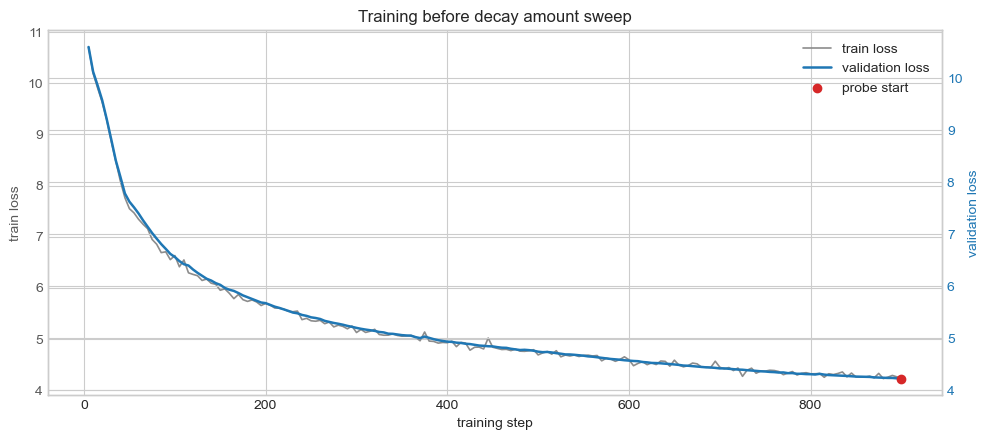

In [5]:
train_rows = metrics[metrics["train_loss"].notna()].copy()
val_curve = metrics[metrics["validation_loss"].notna()].copy()

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(train_rows["step"], train_rows["train_loss"], color="0.55", linewidth=1.2, label="train loss")
ax1.set_xlabel("training step")
ax1.set_ylabel("train loss", color="0.35")
ax1.tick_params(axis="y", labelcolor="0.35")

ax2 = ax1.twinx()
ax2.plot(val_curve["step"], val_curve["validation_loss"], color="tab:blue", linewidth=1.8, label="validation loss")
ax2.scatter([900], [start_val], color="tab:red", zorder=5, label="probe start")
ax2.set_ylabel("validation loss", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title("Training before decay amount sweep")
fig.tight_layout()
plt.show()

## Final Validation Loss vs Decay Amount

The x-axis is logarithmic and inverted: moving right means a stronger LR shrink. The practical question is whether the curve has a clear minimum, or whether differences are tiny relative to the run noise you expect.

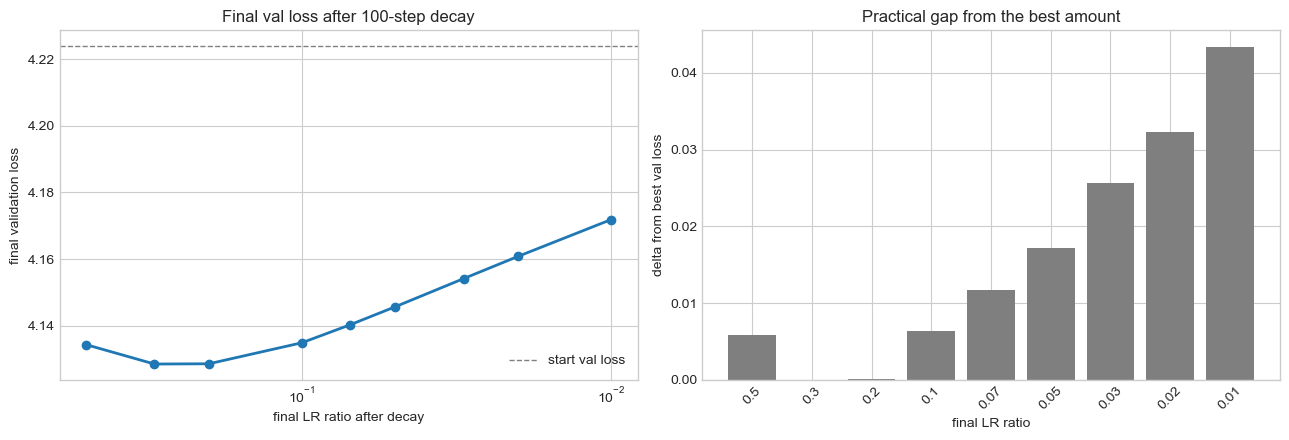

In [6]:
plot_df = sweep.sort_values("final_lr_ratio", ascending=False).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(plot_df["final_lr_ratio"], plot_df["probe_final_val_loss"], marker="o", linewidth=2)
axes[0].axhline(start_val, color="0.5", linestyle="--", linewidth=1, label="start val loss")
axes[0].set_xscale("log")
axes[0].invert_xaxis()
axes[0].set_xlabel("final LR ratio after decay")
axes[0].set_ylabel("final validation loss")
axes[0].set_title("Final val loss after 100-step decay")
axes[0].legend()

axes[1].bar(
    plot_df["final_lr_ratio"].astype(str),
    plot_df["delta_from_best"],
    color=["tab:green" if x == 0 else "tab:gray" for x in plot_df["delta_from_best"]],
)
axes[1].set_xlabel("final LR ratio")
axes[1].set_ylabel("delta from best val loss")
axes[1].set_title("Practical gap from the best amount")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## Validation Loss During The 100-Step Decay

These trajectories show whether different decay amounts separate early, late, or only at the endpoint.

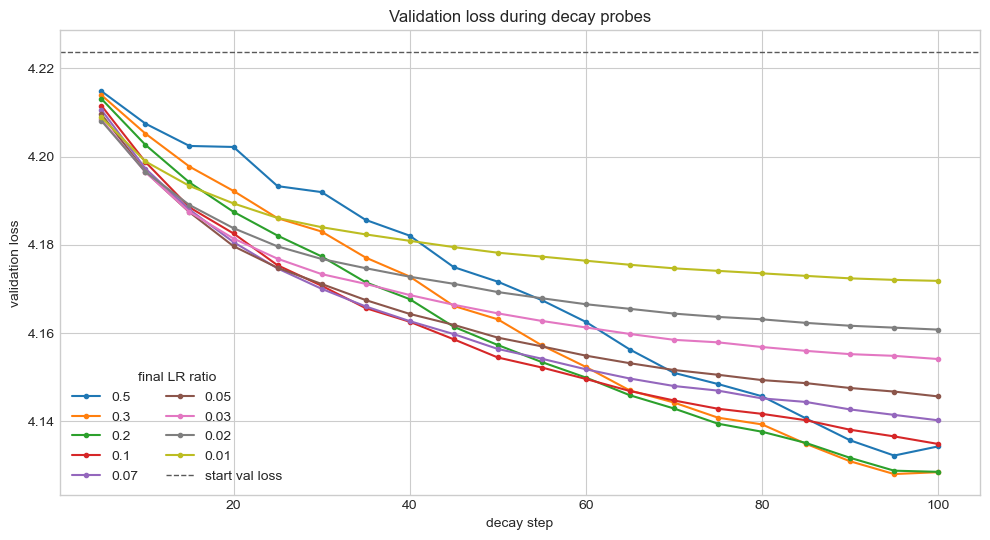

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for ratio, group in trajectory.groupby("final_lr_ratio", sort=False):
    group = group.sort_values("probe_decay_step")
    ax.plot(
        group["probe_decay_step"],
        group["probe_validation_loss"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=f"{ratio:g}",
    )
ax.axhline(start_val, color="0.35", linestyle="--", linewidth=1, label="start val loss")
ax.set_xlabel("decay step")
ax.set_ylabel("validation loss")
ax.set_title("Validation loss during decay probes")
ax.legend(title="final LR ratio", ncols=2)
plt.tight_layout()
plt.show()

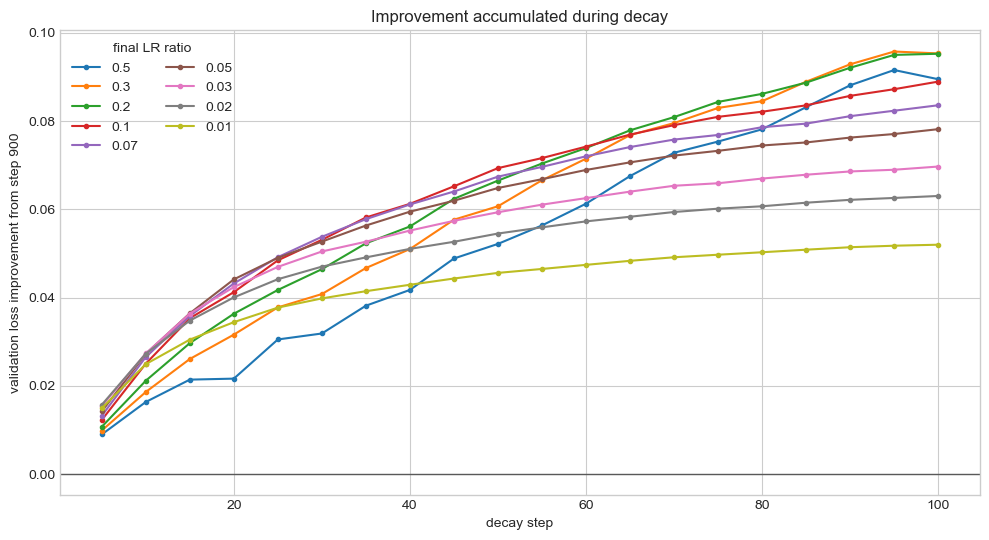

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for ratio, group in trajectory.groupby("final_lr_ratio", sort=False):
    group = group.sort_values("probe_decay_step")
    ax.plot(
        group["probe_decay_step"],
        group["decay_val_improvement"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=f"{ratio:g}",
    )
ax.axhline(0, color="0.35", linewidth=1)
ax.set_xlabel("decay step")
ax.set_ylabel("validation loss improvement from step 900")
ax.set_title("Improvement accumulated during decay")
ax.legend(title="final LR ratio", ncols=2)
plt.tight_layout()
plt.show()

## Learning Rate Trajectories

This confirms the decay schedule actually separates the tested amounts as intended.

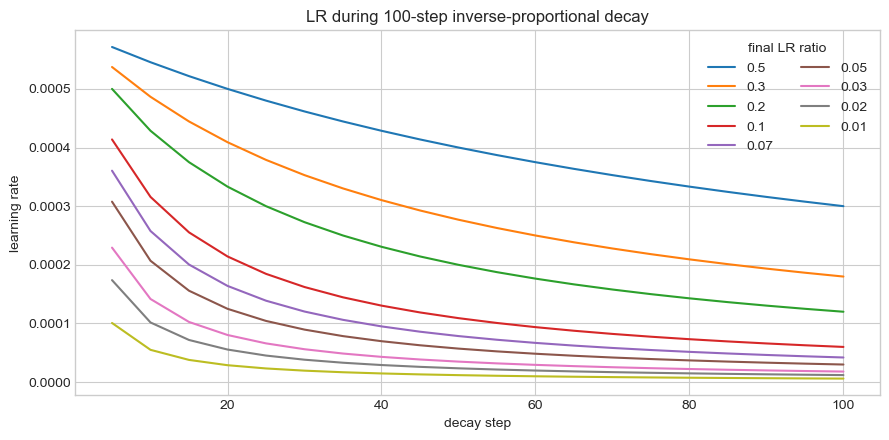

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for ratio, group in trajectory.groupby("final_lr_ratio", sort=False):
    group = group.sort_values("probe_decay_step")
    ax.plot(group["probe_decay_step"], group["probe_learning_rate"], linewidth=1.5, label=f"{ratio:g}")
ax.set_xlabel("decay step")
ax.set_ylabel("learning rate")
ax.set_title("LR during 100-step inverse-proportional decay")
ax.legend(title="final LR ratio", ncols=2)
plt.tight_layout()
plt.show()

## Descriptive Correlations

With one probe start step, optimization metrics such as `grad_snr` and `weight_norm` are constant across decay amounts, so they cannot explain amount differences here. The only meaningful correlations are with the amount variables themselves. These are descriptive only because there are only nine amount settings and no repeated seeds.

In [10]:
corr_cols = ["final_lr_ratio", "log_final_lr_ratio", "lr_drop_fraction"]
y = sweep["probe_final_val_loss"].to_numpy()
rows = []
for col in corr_cols:
    x = sweep[col].to_numpy()
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    rows.append({
        "metric": col,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    })
amount_corr = pd.DataFrame(rows)
amount_corr

,metric,pearson_r,pearson_p,spearman_r,spearman_p
0,final_lr_ratio,-0.660781,0.052675,-0.950000,0.000088
1,log_final_lr_ratio,-0.929860,0.000281,-0.950000,0.000088
2,lr_drop_fraction,0.660781,0.052675,0.950000,0.000088


## Endpoint Separation Over Time

This plot shows the range between the best and worst validation loss across decay amounts at each decay step. If the range remains small, the amount choice is not practically very important for this run.

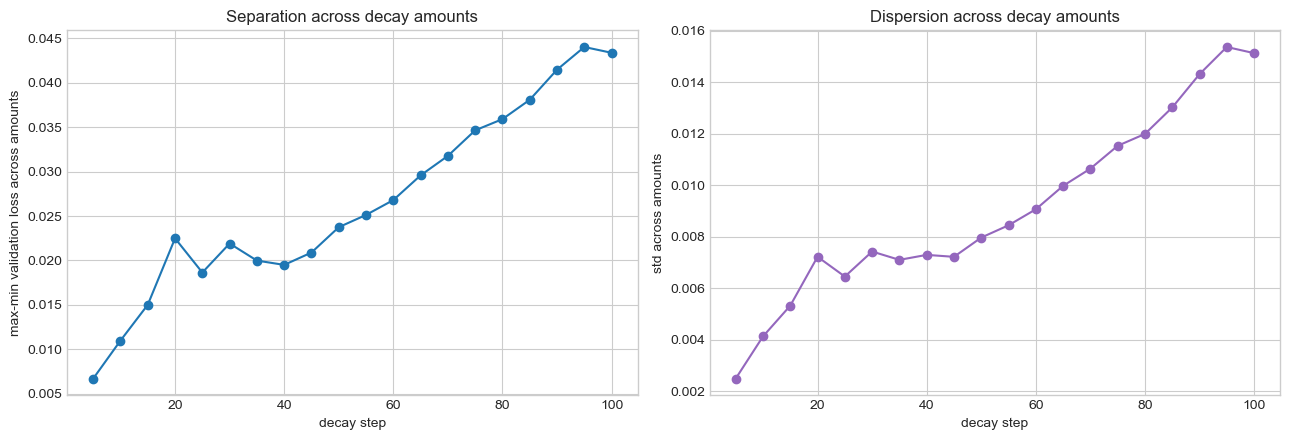

,probe_decay_step,best,worst,mean,std,spread
15,80,4.137681,4.173572,4.150298,0.011991,0.035891
16,85,4.134928,4.172993,4.148387,0.013019,0.038066
17,90,4.130986,4.172434,4.146260,0.014312,0.041448
18,95,4.128090,4.172091,4.144707,0.015367,0.044001
19,100,4.128516,4.171865,4.144350,0.015128,0.043349


In [11]:
spread_by_step = (
    trajectory.groupby("probe_decay_step")["probe_validation_loss"]
    .agg(best="min", worst="max", mean="mean", std="std")
    .reset_index()
)
spread_by_step["spread"] = spread_by_step["worst"] - spread_by_step["best"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(spread_by_step["probe_decay_step"], spread_by_step["spread"], marker="o")
axes[0].set_xlabel("decay step")
axes[0].set_ylabel("max-min validation loss across amounts")
axes[0].set_title("Separation across decay amounts")

axes[1].plot(spread_by_step["probe_decay_step"], spread_by_step["std"], marker="o", color="tab:purple")
axes[1].set_xlabel("decay step")
axes[1].set_ylabel("std across amounts")
axes[1].set_title("Dispersion across decay amounts")

fig.tight_layout()
plt.show()

spread_by_step.tail()

## Interpretation Helper

Use this cell as the concise result summary for the run.

In [12]:
near_best_thresholds = [0.001, 0.002, 0.005, 0.01]
print("Summary")
print("=======")
print(f"Best final LR ratio: {best['final_lr_ratio']:.3g}")
print(f"Best final validation loss: {best['probe_final_val_loss']:.6f}")
print(f"Worst-best final loss spread: {spread:.6f}")
print(f"Best improvement over start val loss: {best['decay_val_improvement']:.6f}")
print()
for threshold in near_best_thresholds:
    close = ranking[ranking["delta_from_best"] <= threshold]["final_lr_ratio"].tolist()
    print(f"Ratios within {threshold:.3f} of best: {close}")

print()
if spread < 0.005:
    print("Interpretation: amount differences are small in absolute validation loss for this single run.")
elif spread < 0.02:
    print("Interpretation: amount differences are visible but still modest; repeat seeds would be needed before claiming significance.")
else:
    print("Interpretation: amount differences are large enough to prioritize follow-up runs around the best ratio.")

Summary
Best final LR ratio: 0.3
Best final validation loss: 4.128516
Worst-best final loss spread: 0.043349
Best improvement over start val loss: 0.095317

Ratios within 0.001 of best: [0.3, 0.2]
Ratios within 0.002 of best: [0.3, 0.2]
Ratios within 0.005 of best: [0.3, 0.2]
Ratios within 0.010 of best: [0.3, 0.2, 0.5, 0.1]

Interpretation: amount differences are large enough to prioritize follow-up runs around the best ratio.
